In [17]:
# importing processed datasets for ML
import pandas as pd

X_train_stress = pd.read_csv("ml_ready_data/X_train_stress.csv")
X_test_stress = pd.read_csv("ml_ready_data/X_test_stress.csv")
y_train_stress = pd.read_csv("ml_ready_data/y_train_stress.csv").squeeze("columns")
y_test_stress = pd.read_csv("ml_ready_data/y_test_stress.csv").squeeze("columns")

X_train_deflection = pd.read_csv("ml_ready_data/X_train_deflection.csv")
X_test_deflection = pd.read_csv("ml_ready_data/X_test_deflection.csv")
y_train_deflection = pd.read_csv("ml_ready_data/y_train_deflection.csv").squeeze("columns")
y_test_deflection = pd.read_csv("ml_ready_data/y_test_deflection.csv").squeeze("columns")

print("Stress model     -> Train:", X_train_stress.shape, " Test:", X_test_stress.shape)
print("Deflection model -> Train:", X_train_deflection.shape, " Test:", X_test_deflection.shape)


Stress model     -> Train: (64, 6)  Test: (17, 6)
Deflection model -> Train: (64, 6)  Test: (17, 6)


# Stress Model

In [18]:
# Model training
from sklearn.ensemble import RandomForestRegressor

stress_model = RandomForestRegressor(n_estimators=100, random_state=42)
stress_model.fit(X_train_stress, y_train_stress)
print("Model trained.")

Model trained.


In [19]:
# Performance
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_stress_pa = stress_model.predict(X_test_stress)

# Convert to MPa for interpretable metrics/plots
y_test_mpa = y_test_stress / 1e6
y_pred_mpa = y_pred_stress_pa / 1e6

mae = mean_absolute_error(y_test_mpa, y_pred_mpa)
rmse = np.sqrt(mean_squared_error(y_test_mpa, y_pred_mpa))
r2 = r2_score(y_test_mpa, y_pred_mpa)

print(f"MAE:  {mae:.3f} MPa")
print(f"RMSE: {rmse:.3f} MPa")
print(f"R²:   {r2:.4f}")

MAE:  1.747 MPa
RMSE: 2.234 MPa
R²:   0.9388


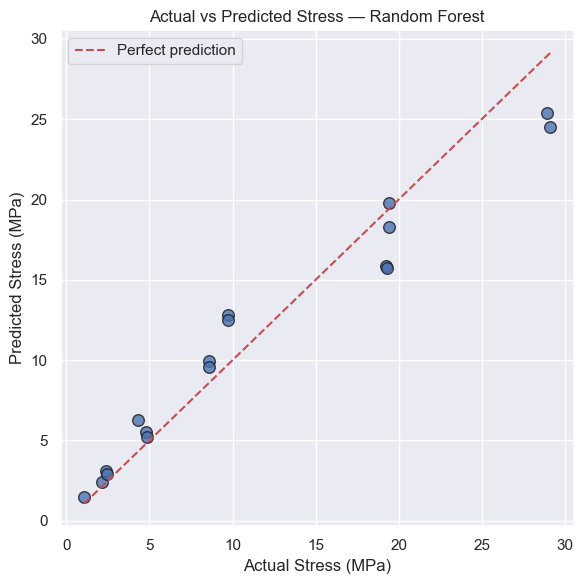

In [20]:
# used AI to refine plots
# Actual vs Predicted
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_mpa, y_pred_mpa, s=70, alpha=0.8, edgecolor="k")
lims = [min(y_test_mpa.min(), y_pred_mpa.min()), max(y_test_mpa.max(), y_pred_mpa.max())]
ax.plot(lims, lims, "r--", label="Perfect prediction")
ax.set_xlabel("Actual Stress (MPa)")
ax.set_ylabel("Predicted Stress (MPa)")
ax.set_title("Actual vs Predicted Stress — Random Forest")
ax.legend()
plt.tight_layout()
plt.show()

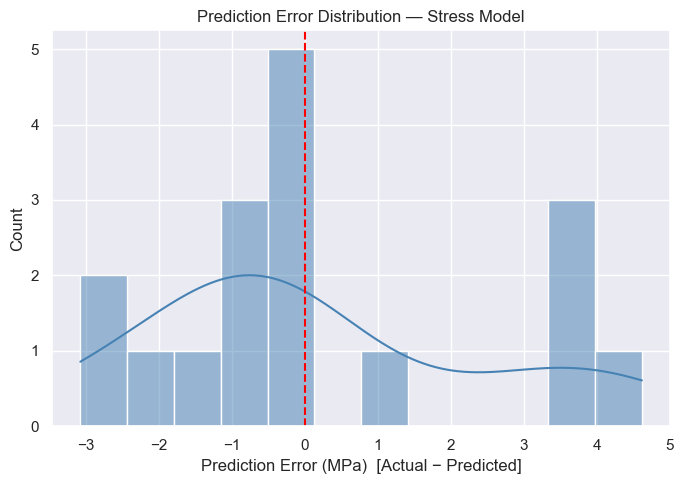

In [21]:
# Prediction error distribution
errors = y_test_mpa - y_pred_mpa

fig, ax = plt.subplots(figsize=(7, 5))
sns.histplot(errors, kde=True, bins=12, color="steelblue", ax=ax)
ax.axvline(0, color="red", linestyle="--")
ax.set_xlabel("Prediction Error (MPa)  [Actual − Predicted]")
ax.set_title("Prediction Error Distribution — Stress Model")
plt.tight_layout()
plt.show()

# Deflection Model

In [22]:
# Deformation model training
deflection_model = RandomForestRegressor(n_estimators=100, random_state=42)
deflection_model.fit(X_train_deflection, y_train_deflection)
print("Model trained.")

Model trained.


In [23]:
# performance
y_pred_defl_m = deflection_model.predict(X_test_deflection)

# Convert to mm for interpretable metrics/plots
y_test_mm = y_test_deflection * 1000
y_pred_mm = y_pred_defl_m * 1000

mae = mean_absolute_error(y_test_mm, y_pred_mm)
rmse = np.sqrt(mean_squared_error(y_test_mm, y_pred_mm))
r2 = r2_score(y_test_mm, y_pred_mm)

print(f"MAE:  {mae:.3f} mm")
print(f"RMSE: {rmse:.3f} mm")
print(f"R²:   {r2:.4f}")

MAE:  11.299 mm
RMSE: 20.172 mm
R²:   0.6962


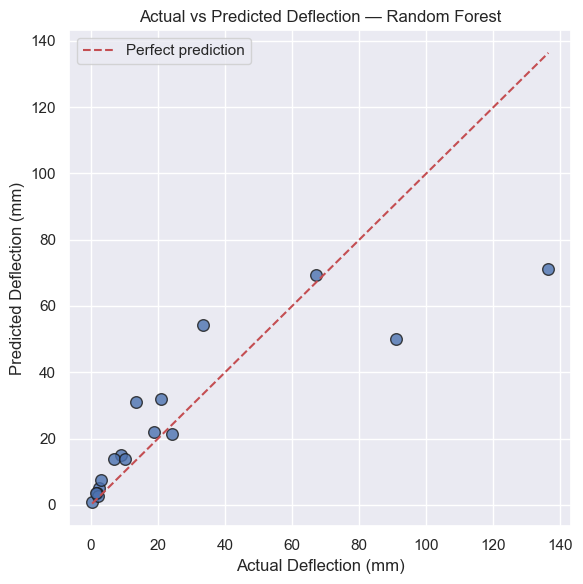

In [24]:
# Actual vs predicted
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_mm, y_pred_mm, s=70, alpha=0.8, edgecolor="k")
lims = [min(y_test_mm.min(), y_pred_mm.min()), max(y_test_mm.max(), y_pred_mm.max())]
ax.plot(lims, lims, "r--", label="Perfect prediction")
ax.set_xlabel("Actual Deflection (mm)")
ax.set_ylabel("Predicted Deflection (mm)")
ax.set_title("Actual vs Predicted Deflection — Random Forest")
ax.legend()
plt.tight_layout()
plt.show()

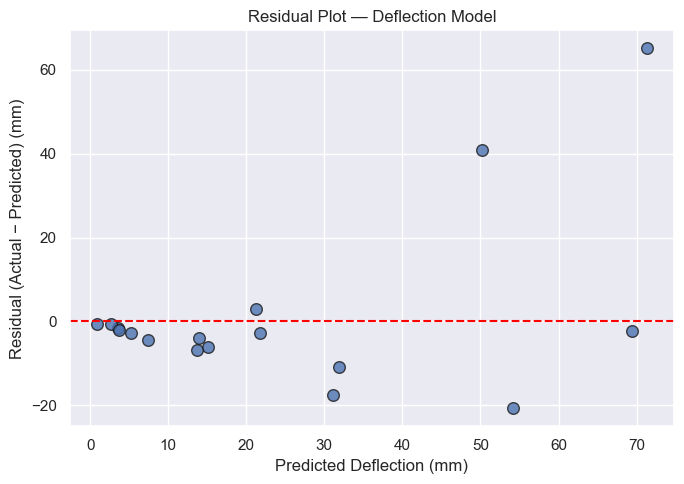

In [25]:
# Residual Plot
residuals = y_test_mm - y_pred_mm

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_pred_mm, residuals, s=70, alpha=0.8, edgecolor="k")
ax.axhline(0, color="red", linestyle="--")
ax.set_xlabel("Predicted Deflection (mm)")
ax.set_ylabel("Residual (Actual − Predicted) (mm)")
ax.set_title("Residual Plot — Deflection Model")
plt.tight_layout()
plt.show()

# Feature Importance

Feature Importance — Stress Model
Root_Chord_mm            0.381357
Blade_Length_m           0.345577
Applied_Load_Pa          0.250966
Material_Fiberglass      0.008813
Material_Aluminium       0.006814
Material_Carbon fiber    0.006472
dtype: float64


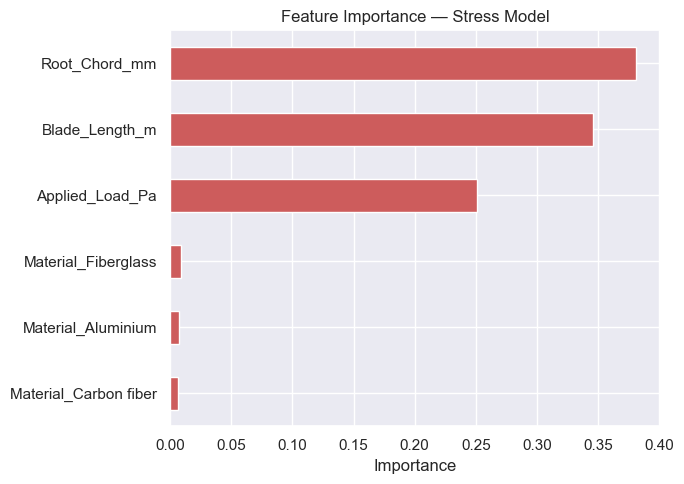

In [26]:
# Stress model
stress_importance = pd.Series(
    stress_model.feature_importances_, index=X_train_stress.columns
).sort_values(ascending=False)

print("Feature Importance — Stress Model")
print(stress_importance)

fig, ax = plt.subplots(figsize=(7, 5))
stress_importance.plot(kind="barh", ax=ax, color="indianred")
ax.invert_yaxis()
ax.set_xlabel("Importance")
ax.set_title("Feature Importance — Stress Model")
plt.tight_layout()
plt.show()

Feature Importance — Deflection Model
Root_Chord_mm            0.289653
Blade_Length_m           0.274046
Material_Fiberglass      0.264661
Applied_Load_Pa          0.150665
Material_Carbon fiber    0.011040
Material_Aluminium       0.009934
dtype: float64


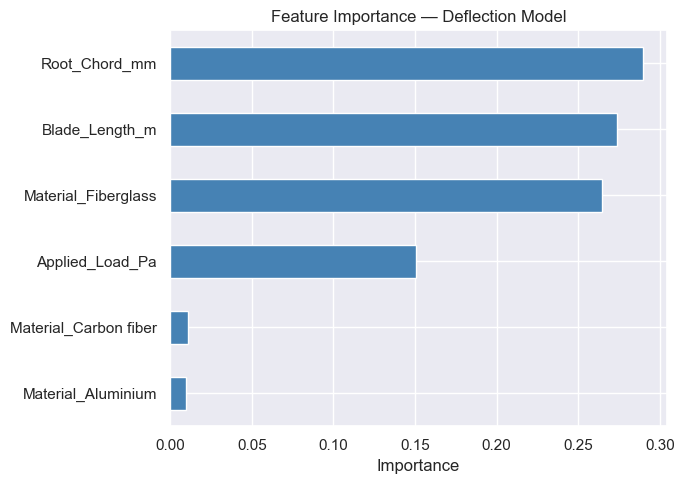

In [27]:
# Deformation model
deflection_importance = pd.Series(
    deflection_model.feature_importances_, index=X_train_deflection.columns
).sort_values(ascending=False)

print("Feature Importance — Deflection Model")
print(deflection_importance)

fig, ax = plt.subplots(figsize=(7, 5))
deflection_importance.plot(kind="barh", ax=ax, color="steelblue")
ax.invert_yaxis()
ax.set_xlabel("Importance")
ax.set_title("Feature Importance — Deflection Model")
plt.tight_layout()
plt.show()

# Model Optimisation

In [28]:
# Grid search setup
import itertools
import pickle
import os

n_trees_opts = [50, 100, 200, 300]
max_depth_opts = [5, 10, 20, None]
min_split_opts = [2, 5, 10]

def run_experiments(X_train, X_test, y_train, y_test, unit_divisor=1.0):
    """unit_divisor converts raw units (Pa or m) to readable units (MPa or mm) for metrics only."""
    records = []
    for nt, md, ms in itertools.product(n_trees_opts, max_depth_opts, min_split_opts):
        model = RandomForestRegressor(n_estimators=nt, max_depth=md, min_samples_split=ms, random_state=42)
        model.fit(X_train, y_train)
        pred_test = model.predict(X_test) / unit_divisor
        pred_train = model.predict(X_train) / unit_divisor
        y_test_u = y_test / unit_divisor
        y_train_u = y_train / unit_divisor
        records.append({
            "n_estimators": nt, "max_depth": md, "min_samples_split": ms,
            "MAE": mean_absolute_error(y_test_u, pred_test),
            "RMSE": np.sqrt(mean_squared_error(y_test_u, pred_test)),
            "R2_test": r2_score(y_test_u, pred_test),
            "R2_train": r2_score(y_train_u, pred_train),
        })
    results_df = pd.DataFrame(records)
    results_df["overfit_gap"] = results_df["R2_train"] - results_df["R2_test"]
    return results_df

In [29]:
# Running for both models
# Stress: y is in Pa, divide by 1e6 for MPa
stress_results = run_experiments(X_train_stress, X_test_stress, y_train_stress, y_test_stress, unit_divisor=1e6)

# Deflection: y is in metres, divide by 0.001 (i.e. multiply by 1000) for mm
deflection_results = run_experiments(X_train_deflection, X_test_deflection, y_train_deflection, y_test_deflection, unit_divisor=0.001)

print("Top 5 configs — Stress (by R² test):")
print(stress_results.sort_values("R2_test", ascending=False).head(5))
print("\nTop 5 configs — Deflection (by R² test):")
print(deflection_results.sort_values("R2_test", ascending=False).head(5))

Top 5 configs — Stress (by R² test):
    n_estimators  max_depth  min_samples_split       MAE      RMSE   R2_test  \
0             50        5.0                  2  1.615171  2.159321  0.942827   
12           100        5.0                  2  1.752571  2.184249  0.941499   
45           300        NaN                  2  1.692793  2.200655  0.940617   
42           300       20.0                  2  1.692793  2.200655  0.940617   
39           300       10.0                  2  1.692793  2.200655  0.940617   

    R2_train  overfit_gap  
0   0.988333     0.045506  
12  0.989771     0.048272  
45  0.992523     0.051906  
42  0.992523     0.051906  
39  0.992523     0.051906  

Top 5 configs — Deflection (by R² test):
    n_estimators  max_depth  min_samples_split        MAE       RMSE  \
15           100       10.0                  2  11.299385  20.171816   
18           100       20.0                  2  11.299385  20.171816   
21           100        NaN                  2  11.29938

In [30]:
# Baseline Comparison
def show_baseline(results_df, label):
    baseline = results_df[(results_df.n_estimators == 100) &
                           (results_df.max_depth.isna()) &
                           (results_df.min_samples_split == 2)]
    print(f"--- {label} baseline ---")
    print(baseline)

show_baseline(stress_results, "Stress")
show_baseline(deflection_results, "Deflection")

--- Stress baseline ---
    n_estimators  max_depth  min_samples_split       MAE      RMSE   R2_test  \
21           100        NaN                  2  1.747226  2.233932  0.938808   

    R2_train  overfit_gap  
21  0.991436     0.052628  
--- Deflection baseline ---
    n_estimators  max_depth  min_samples_split        MAE       RMSE  \
21           100        NaN                  2  11.299385  20.171816   

     R2_test  R2_train  overfit_gap  
21  0.696186  0.967013     0.270828  
